In [1]:
# utils
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

#sk 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold

#plot
import matplotlib.pyplot as plt


##### Technical procedure:
- get cell states (predictors) and matching temp timeseries (target) (matching regarding the 365 warmup and also the inherent availability of discharge data maybe use dates)
- split into train- and test-set and train, return R² and RMSE 

_notes:_
- _don't return dataset, but return model and metadata (train period, test period, metrics)_

In [2]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
	cell_states = pickle.load(f)

In [3]:
with open("/home/wuhlmann/BA/data/processed_data/eda/normal_periods.pkl", "rb") as f: 
	discharge_coverage = pickle.load(f)

In [4]:
discharge_coverage.loc[1,:]

timeseries_length                                                     8036
start_date                                             1996-01-01 00:00:00
end_date                                               2017-12-31 00:00:00
n_normal_days                                                         7098
q5_q95_normal_periods    [[1996-01-04 00:00:00, 1996-01-05 00:00:00], [...
Name: 1, dtype: object

In [5]:
ts_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily")

diff of ts and c len: 0
R2 of 0.93 | MAE of 1.470405110258113
R2 of 0.93 | MAE of 1.454923040853074
R2 of 0.93 | MAE of 1.532552804976333
R2 of 0.93 | MAE of 1.5399377085958013
R2 of 0.93 | MAE of 1.4477447723646504
diff of ts and c len: 0
R2 of 0.90 | MAE of 1.9187086850135833
R2 of 0.92 | MAE of 1.7481938045213126
R2 of 0.91 | MAE of 1.9252409475700154
R2 of 0.91 | MAE of 1.8765682311120728
R2 of 0.90 | MAE of 2.0018861085387902


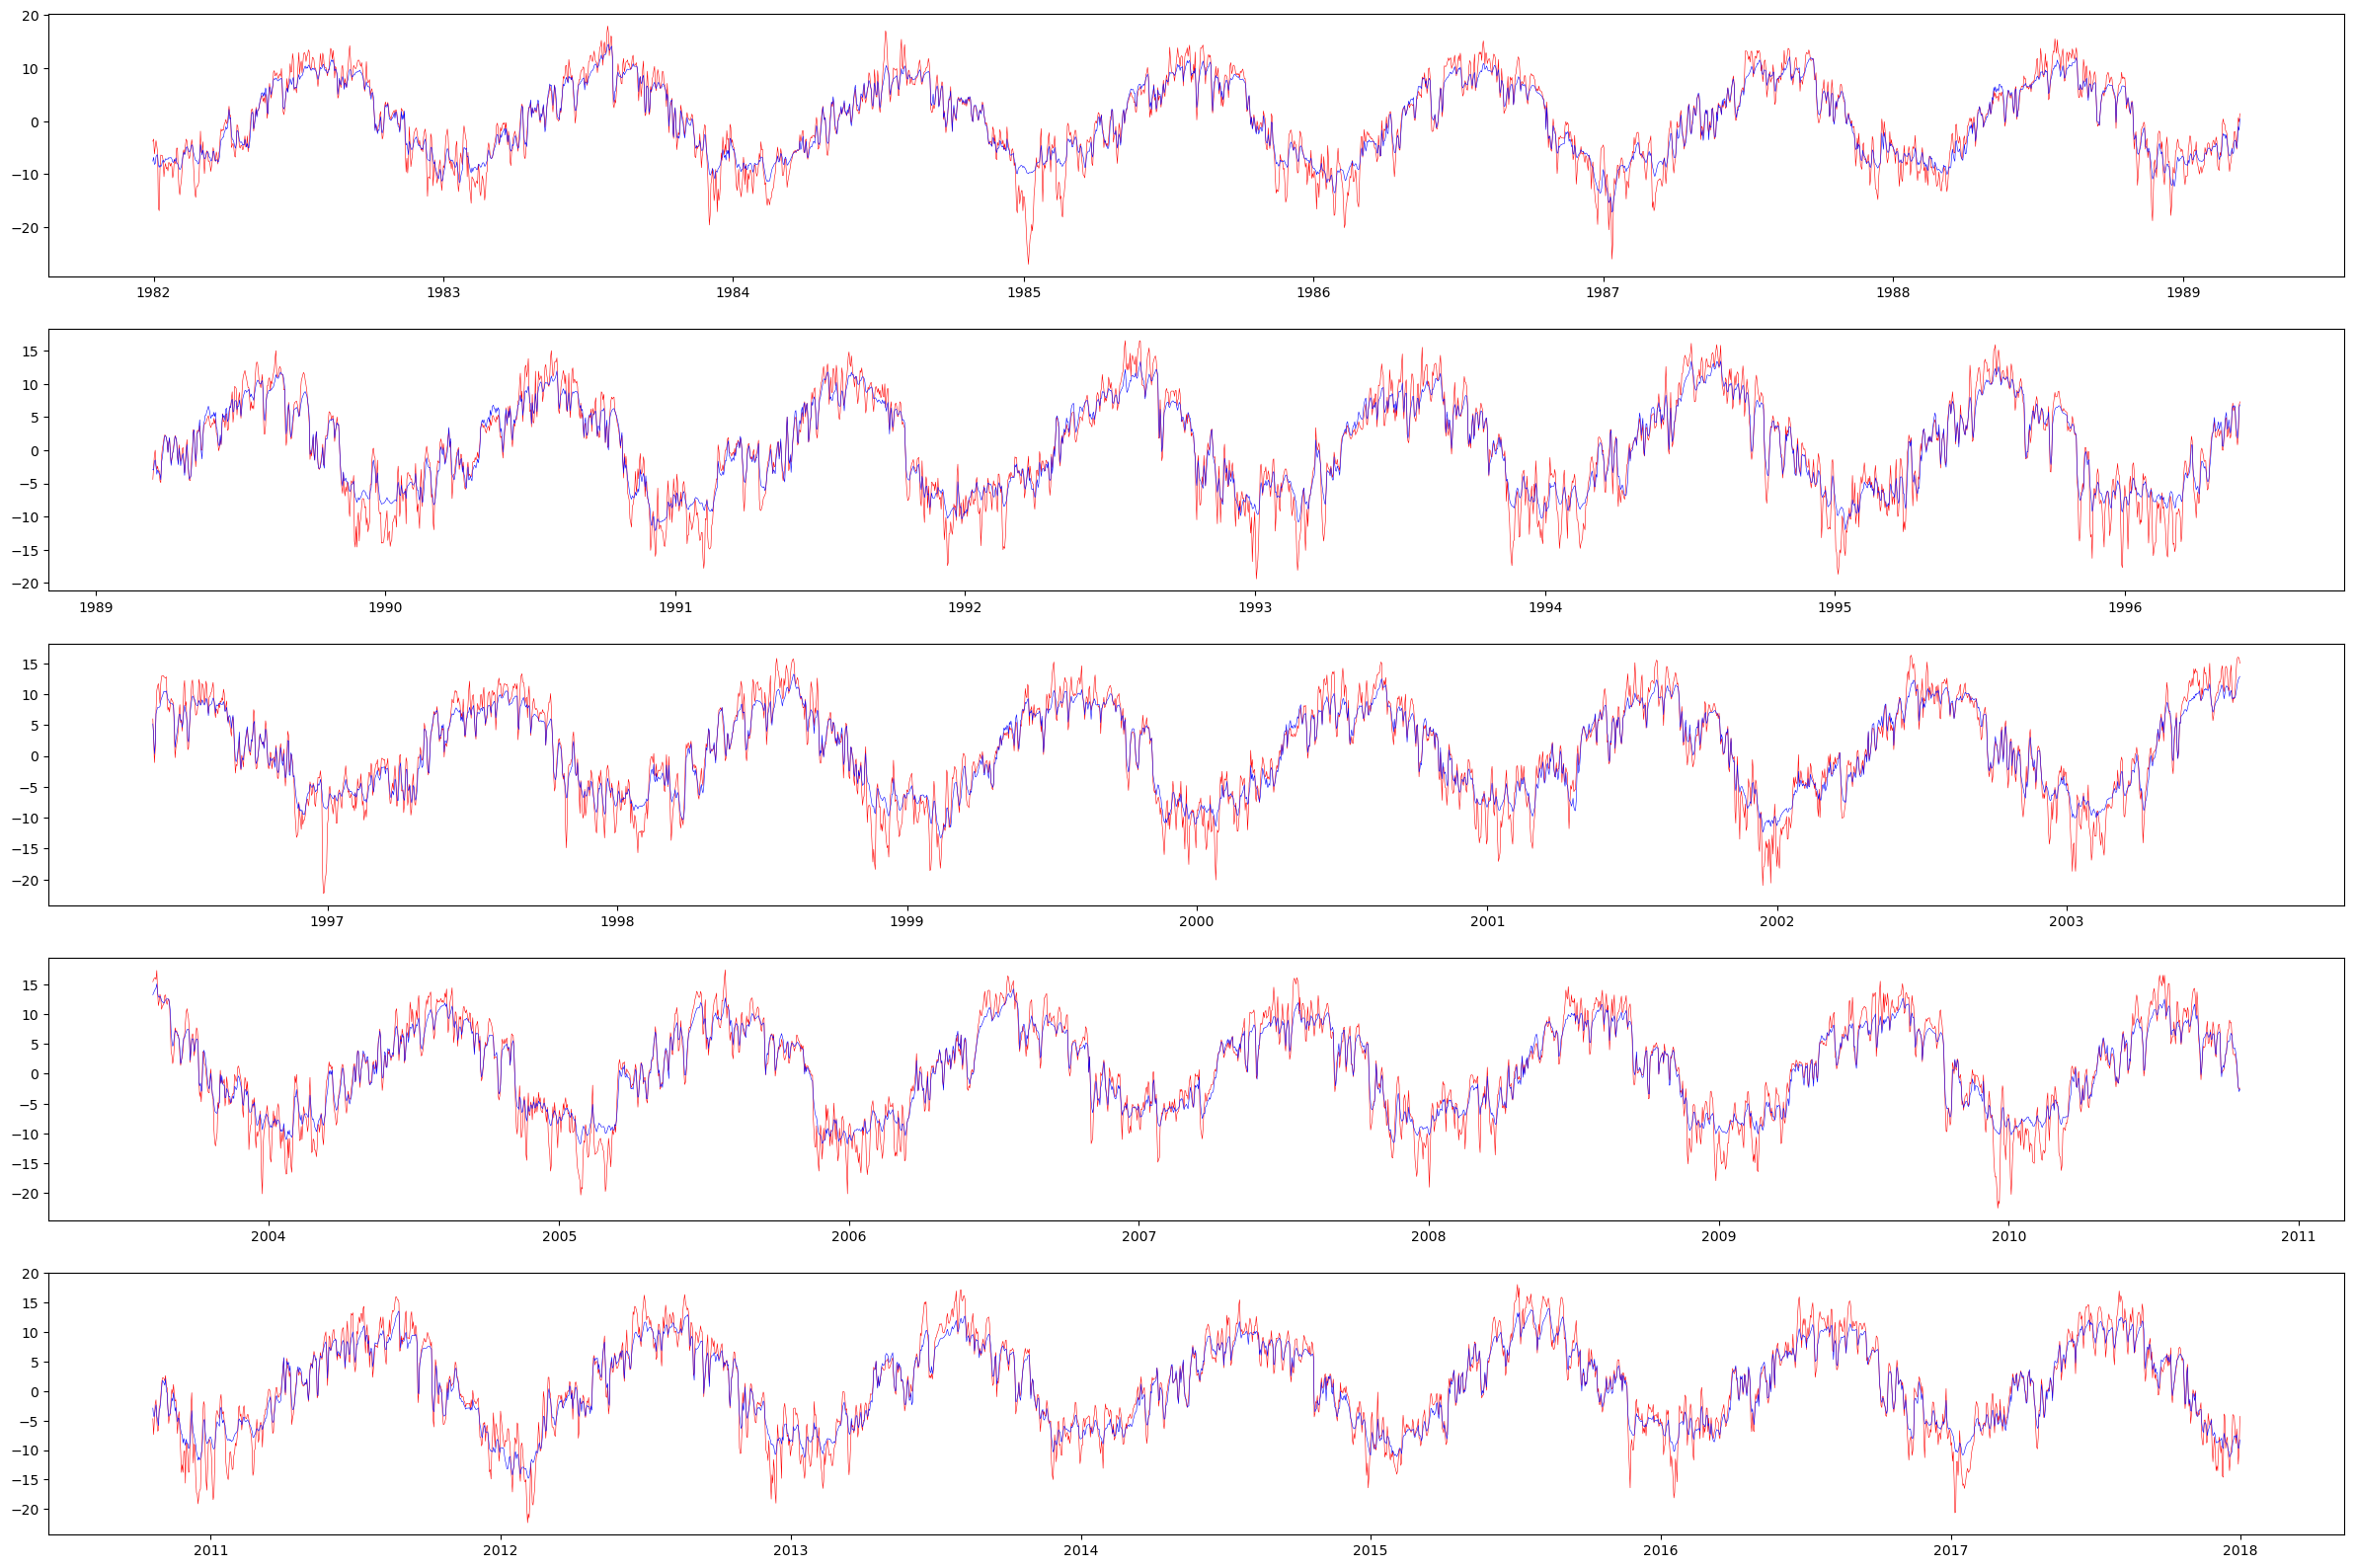

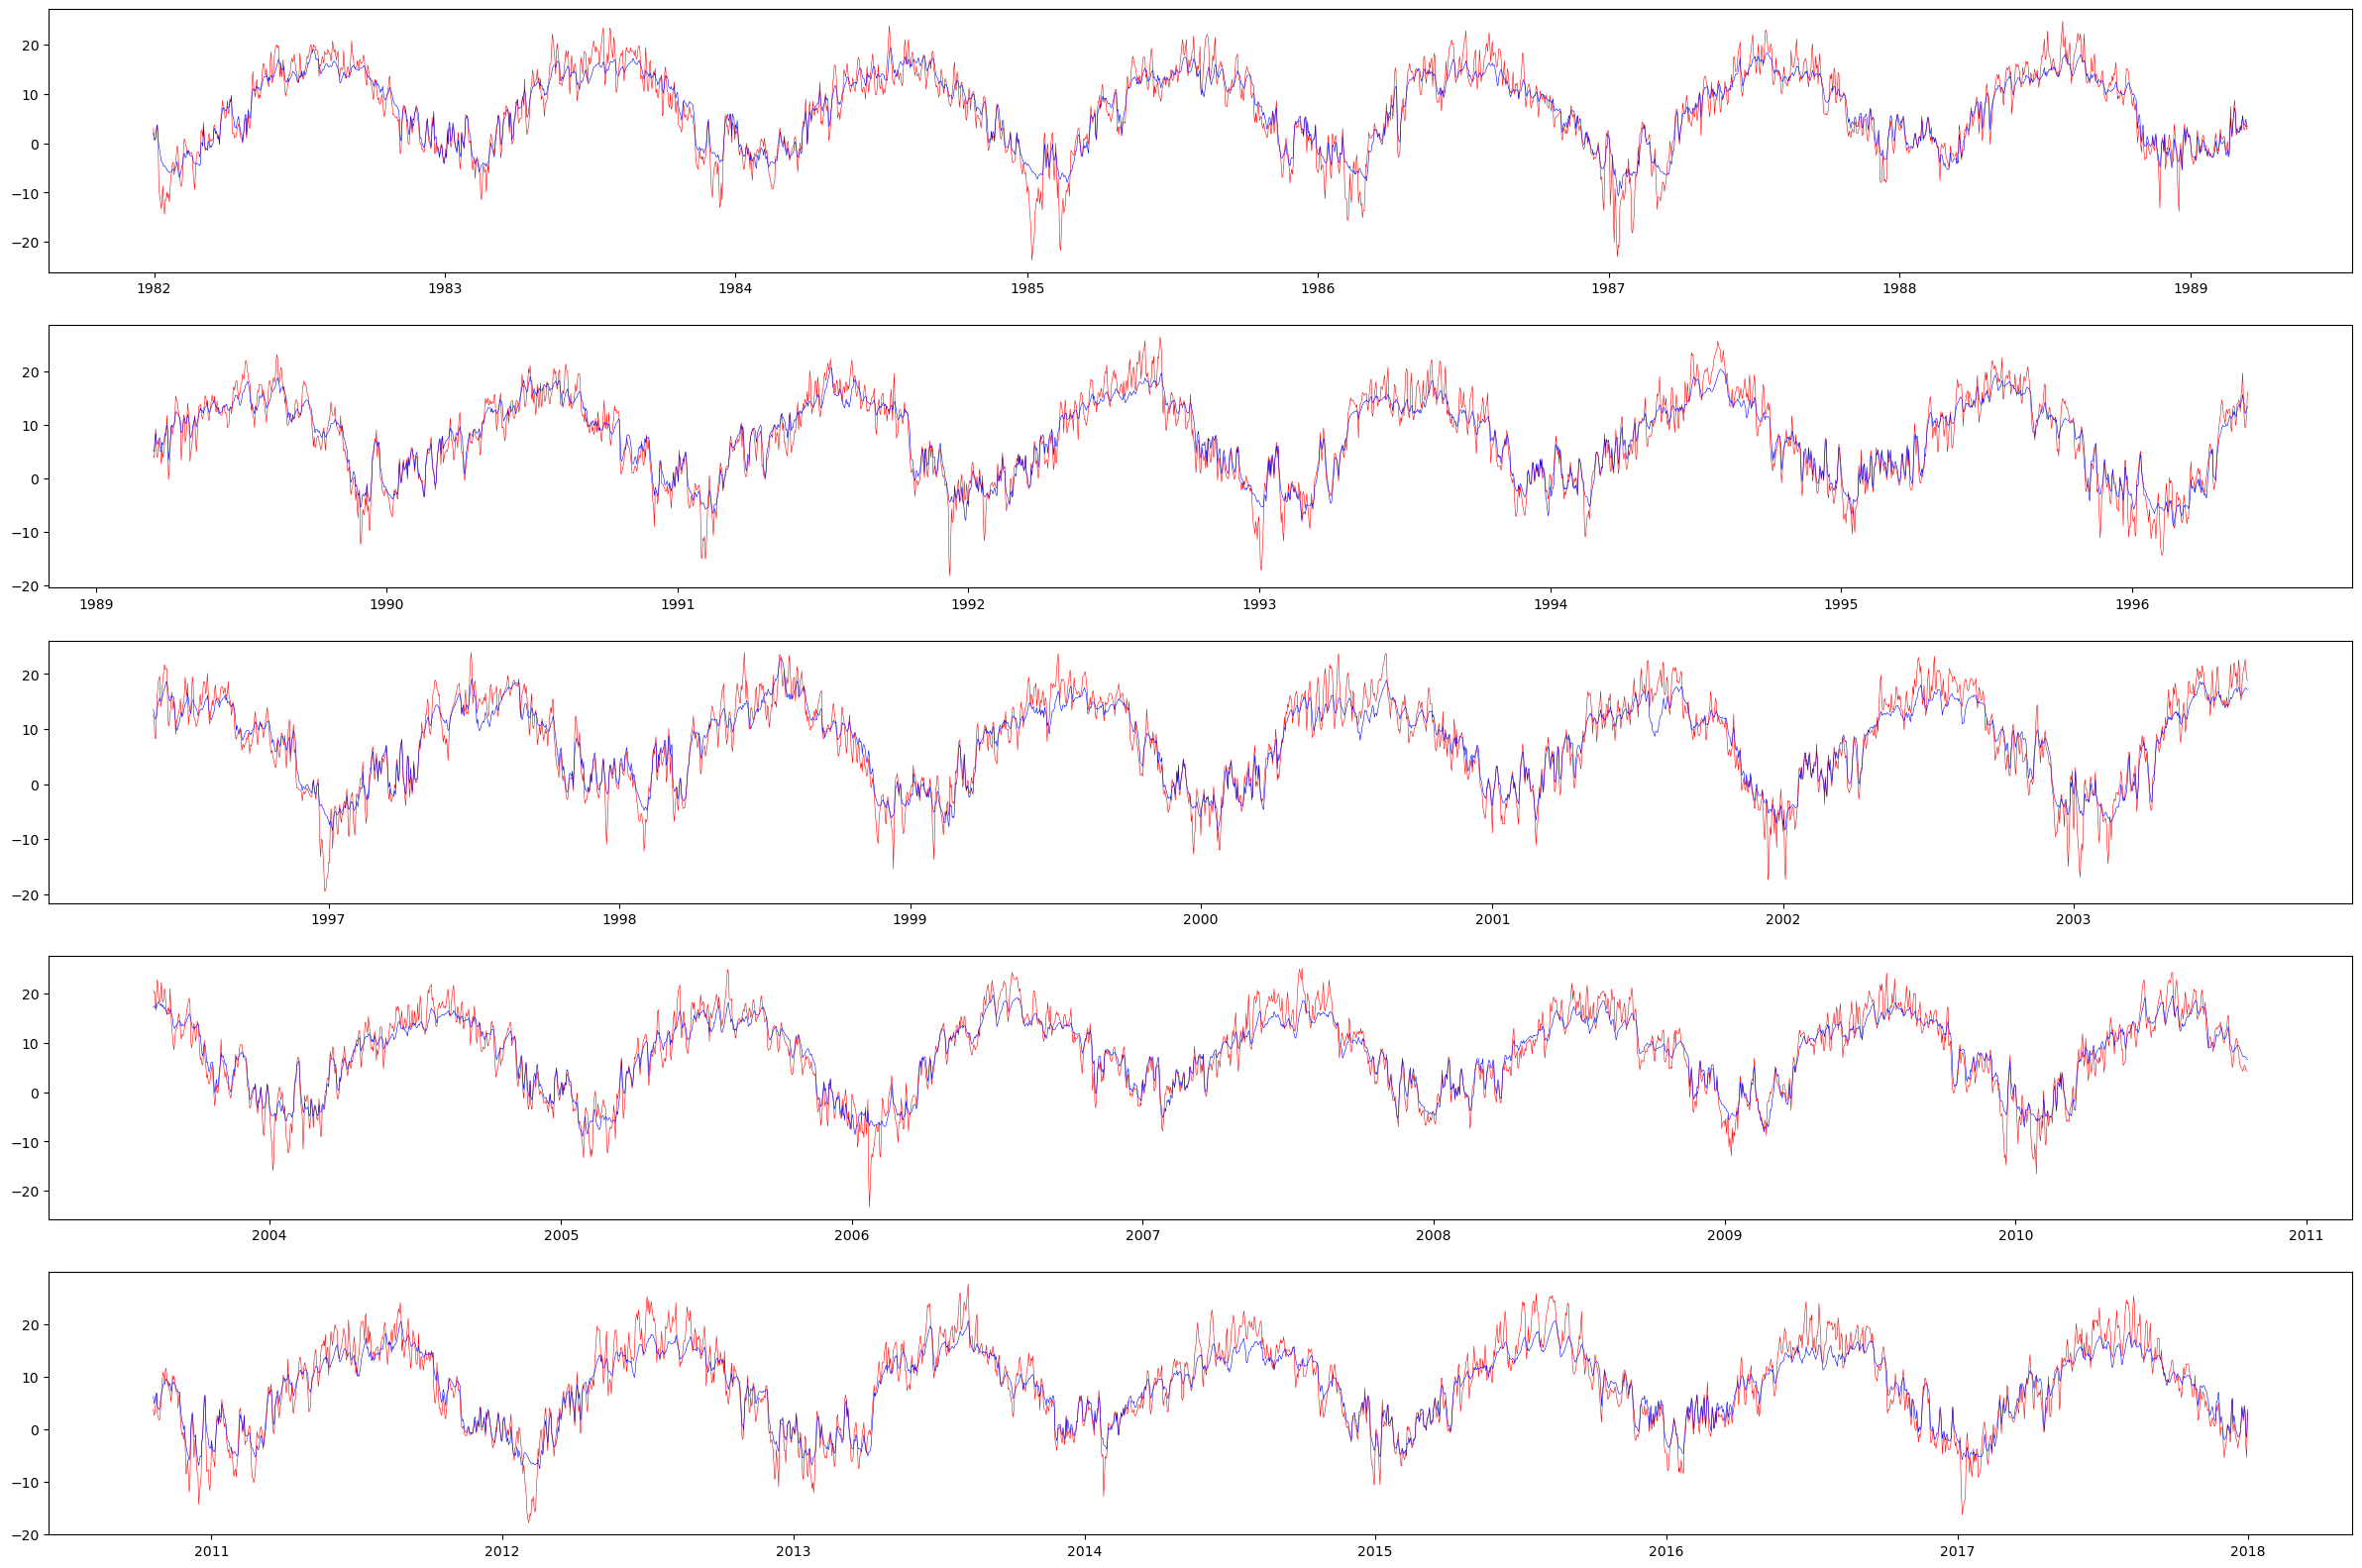

In [6]:
path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily")
model_coef = []

for basin_id in [115, 834]: 

	ts = pd.read_table(ts_path / f"ID_{basin_id}.csv", header=0, sep=";")

	ts["date"] = pd.to_datetime(
				ts[["YYYY", "MM", "DD"]].rename(columns={"YYYY": "year", "MM": "month", "DD": "day"})
			)
	ts.set_index("date", inplace=True)

	# drop all columns except for 2m_mean_temp
	ts = ts[["2m_temp_mean"]]

	ts  = ts[discharge_coverage.loc[basin_id,"start_date"]:discharge_coverage.loc[basin_id, "end_date"]]
	c = StandardScaler().fit_transform(cell_states[str(basin_id)]["c_last"])
	
	ts =ts.iloc[-len(c):]
	
	print(f"diff of ts and c len: {len(ts) -len(c)}")
	dataset = np.c_[c, ts.values]

	model = ElasticNet()
	kfold = KFold(n_splits=5)
	folds = list(kfold.split(dataset[:,:-1], dataset[:,-1]))

	fig, axs = plt.subplots(5,1, figsize=(30,20))

	best_r2 = -100
	best_model_id = None
	coef_list = []

	for i, f, ax in zip([0,1,2,3,4],folds, axs):
		
		train_ids = f[0]
		test_ids = f[1]

		target = dataset[:,-1][test_ids]

		model.fit(X=dataset[:,:-1][train_ids], y=dataset[:,-1][train_ids])
		pred = model.predict(X=dataset[:,:-1][test_ids])

		coef_list.append(model.coef_)

		r2 = r2_score(target, pred)

		if r2 > best_r2: 
			best_r2 = r2
			best_model_id = i

		print(f"R2 of {r2:.2f} | MAE of {mean_absolute_error(target, pred)}")

		ax.plot(ts.index[test_ids], target, color="red", linewidth=0.4)
		ax.plot(ts.index[test_ids], pred, color="blue", linewidth=0.4)

	model_coef.append(coef_list[best_model_id])


In [7]:
model_coef = StandardScaler().fit_transform(model_coef)

<Axes: >

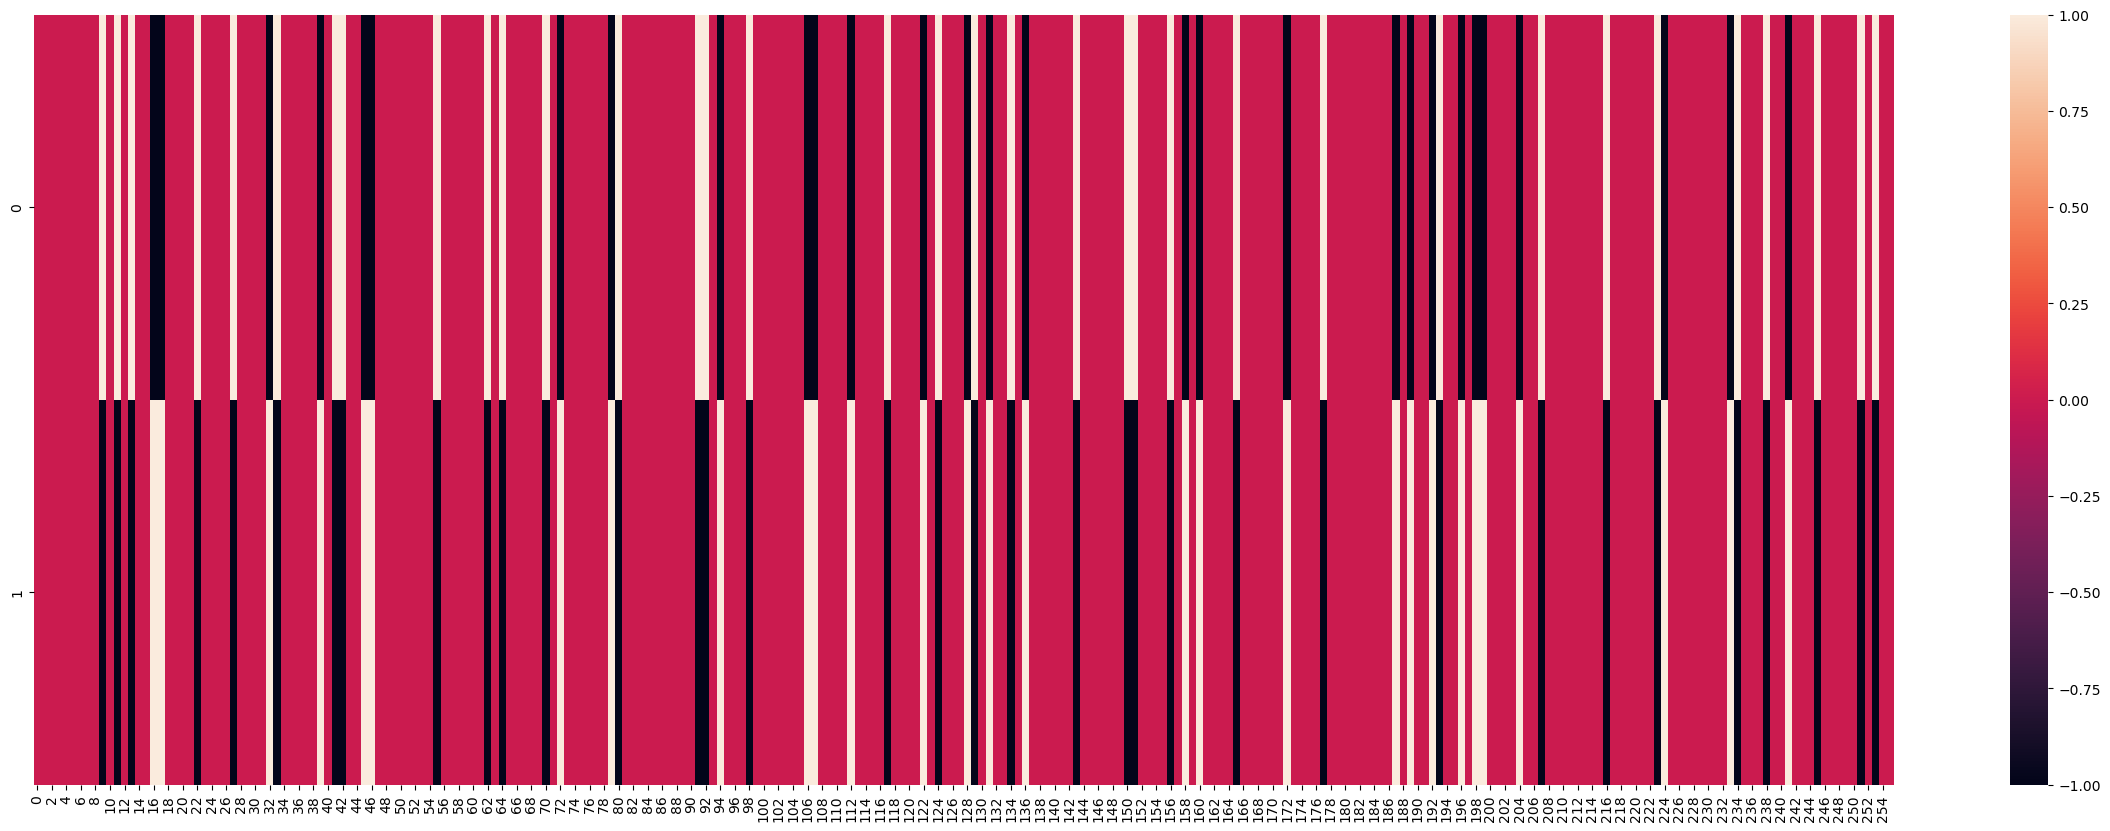

In [8]:
import seaborn as sns

fig = plt.figure(figsize=(30,10))
ax = fig.add_subplot(111)
sns.heatmap(np.vstack(list(map(lambda x: x.reshape(1,256), model_coef))), ax=ax)

we use c of day of prediction, since it most acuratly represents the condition of the day the model predicts

In [9]:
for coef in model_coef: 
	
	print(sorted((-coef).argsort()[:5]))

[33, 41, 42, 129, 223]
[32, 106, 189, 196, 199]


In [10]:
with open("/home/wuhlmann/BA/data/processed_data/probing/full_q_512_3011_185525_cell_states_probing.p", "rb") as f: 
    probing_results = pickle.load(f)

In [11]:
rtwos = [probing_results[b]["R2"] for b in probing_results.keys()]
maes = [probing_results[b]["MAE"] for b in probing_results.keys()]
weights = [probing_results[b]["coef"] for b in probing_results.keys()]
w_stack = np.vstack(weights)

In [12]:
non_zero_w = np.where(w_stack != 0, w_stack, np.nan)

In [13]:
weights_df = pd.DataFrame(w_stack)

In [14]:
always_on= (weights_df == 0).all()
print(always_on.index[always_on])

Index([0, 37, 52, 61, 82, 96, 103, 108, 118, 132, 133, 205, 218], dtype='int64')


<Axes: >

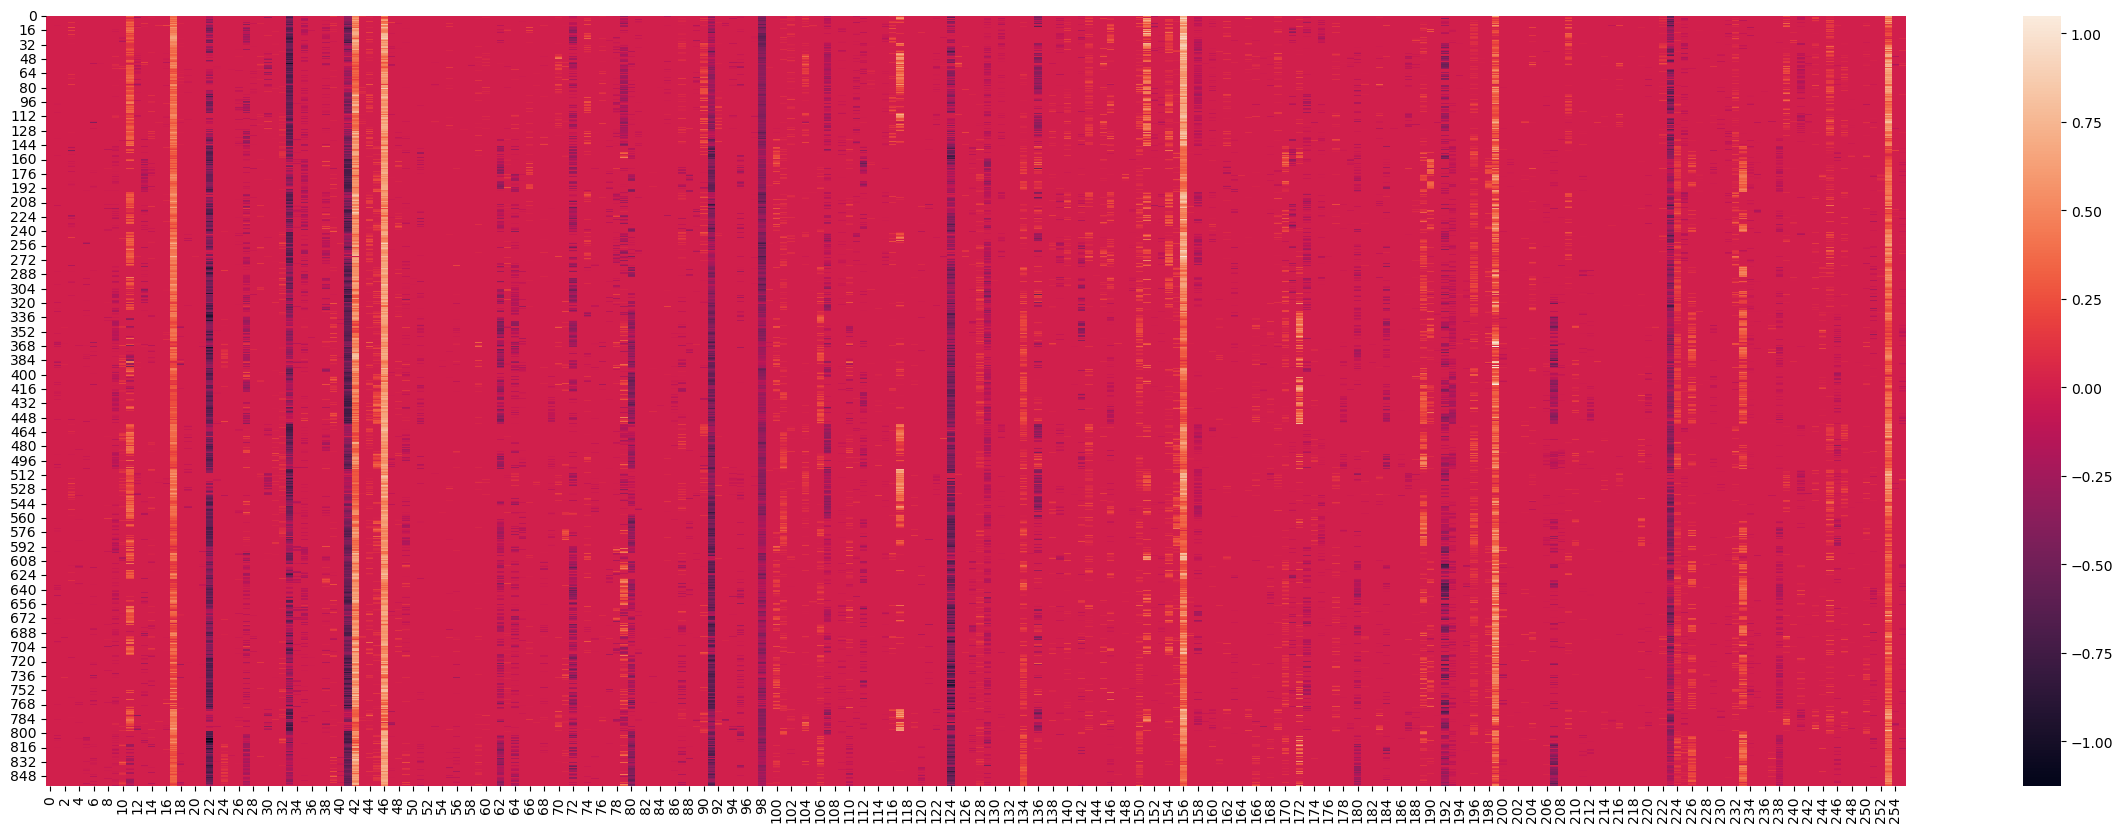

In [22]:
fig = plt.figure(figsize=(30,10))
ax = fig.add_subplot(111)
sns.heatmap(weights_df, ax=ax)

<Axes: >

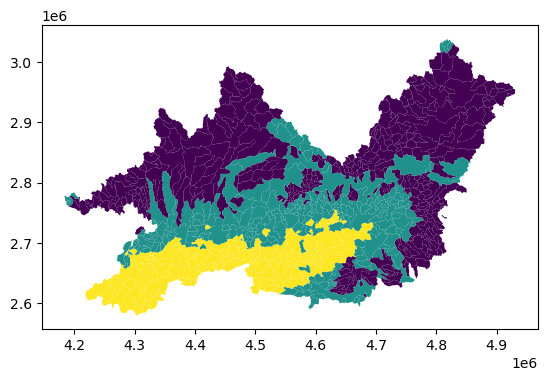

In [17]:
import geopandas as gpd 
from sklearn.cluster import KMeans

lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf.sort_index(ascending=True, inplace=True)

kmeans = KMeans(3, random_state=42)

probe_weights_labels = kmeans.fit_predict(weights_df)

lamah_gdf["probe_labels"] = probe_weights_labels
lamah_gdf.plot(column="probe_labels")